# Succession Planning Analysis

## Objective
Ensure critical roles have identified, ready successors to minimize business disruption.

## Key Questions
1. Which roles are critical to business continuity?
2. Do we have successors identified for each critical role?
3. How ready are potential successors?
4. Where is our succession bench strength weakest?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Load data
print("Loading succession planning data...")
workforce = pd.read_csv('../data/current_workforce.csv')
critical_roles = pd.read_csv('../data/critical_roles.csv')
succession = pd.read_csv('../data/succession_plans.csv')

print(f"Workforce: {len(workforce)} employees")
print(f"Critical roles: {len(critical_roles)} roles")
print(f"Succession plans: {len(succession)} successors identified")

Loading succession planning data...
Workforce: 525 employees
Critical roles: 8 roles
Succession plans: 8 successors identified


## 1. Critical Roles Inventory

In [2]:
# Summary of critical roles
print("\nCRITICAL ROLES INVENTORY")
print("="*90)
print(critical_roles[['role_name', 'department', 'job_level', 'criticality', 
                      'incumbent_retirement_risk']].to_string(index=False))
print("="*90)

# Criticality breakdown
print("\nCriticality Distribution:")
criticality_counts = critical_roles['criticality'].value_counts()
for level, count in criticality_counts.items():
    pct = (count / len(critical_roles)) * 100
    print(f"  {level}: {count} roles ({pct:.1f}%)")

# Retirement risk
retirement_risk_count = critical_roles['incumbent_retirement_risk'].sum()
print(f"\nIncumbents at retirement risk: {retirement_risk_count} of {len(critical_roles)} ({retirement_risk_count/len(critical_roles)*100:.1f}%)")


CRITICAL ROLES INVENTORY
                       role_name  department      job_level criticality  incumbent_retirement_risk
                  VP Engineering Engineering             VP        High                          0
 Director of Backend Engineering Engineering       Director        High                          0
Director of Frontend Engineering Engineering       Director        High                          0
  Engineering Manager - Platform Engineering Senior Manager      Medium                          0
             Director of Product     Product       Director        High                          0
    Director of Enterprise Sales       Sales       Director        High                          0
        Director of Data Science        Data       Director        High                          0
            Data Science Manager        Data Senior Manager      Medium                          0

Criticality Distribution:
  High: 6 roles (75.0%)
  Medium: 2 roles (25.0%)

Incum

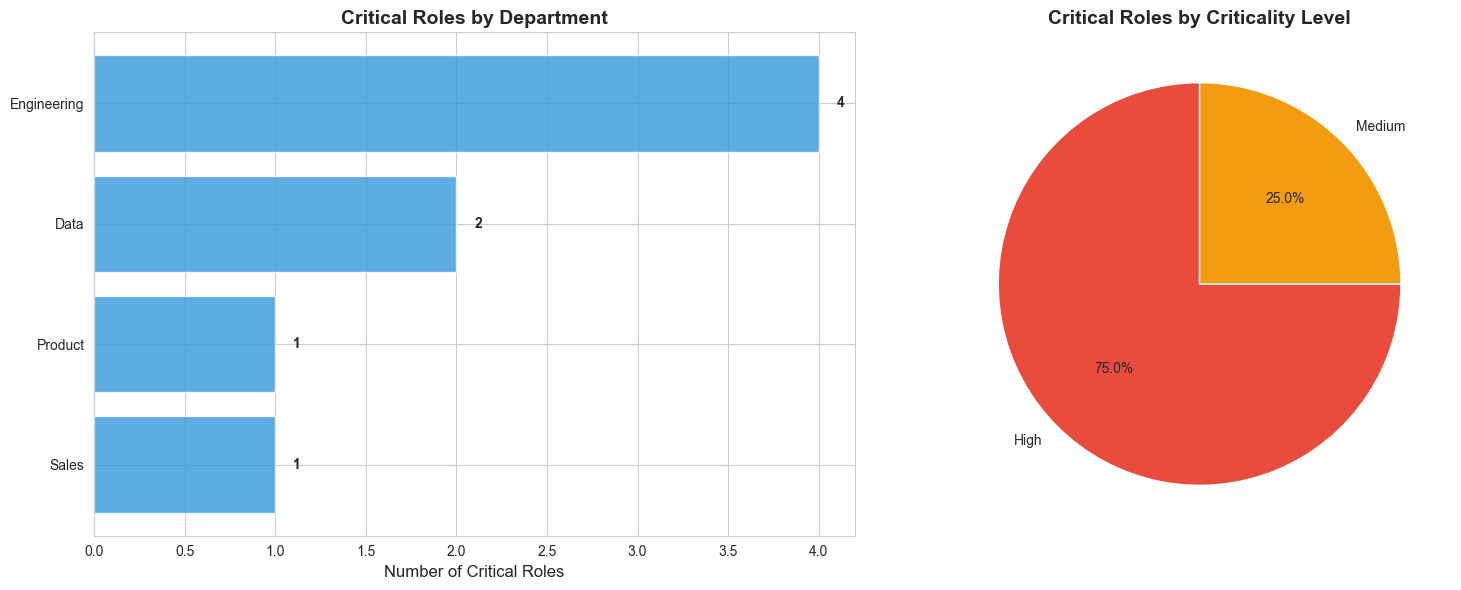

In [3]:
# Visualize critical roles
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Critical roles by department
dept_counts = critical_roles['department'].value_counts()
ax1.barh(range(len(dept_counts)), dept_counts.values, color='#3498db', alpha=0.8)
ax1.set_yticks(range(len(dept_counts)))
ax1.set_yticklabels(dept_counts.index)
ax1.set_xlabel('Number of Critical Roles', fontsize=12)
ax1.set_title('Critical Roles by Department', fontsize=14, fontweight='bold')
ax1.invert_yaxis()

# Add value labels
for i, val in enumerate(dept_counts.values):
    ax1.text(val + 0.1, i, str(val), va='center', fontweight='bold')

# Criticality pie chart
colors_pie = ['#e74c3c', '#f39c12', '#95a5a6']
ax2.pie(criticality_counts.values, labels=criticality_counts.index, 
        autopct='%1.1f%%', colors=colors_pie, startangle=90)
ax2.set_title('Critical Roles by Criticality Level', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Succession Coverage Analysis

In [4]:
# Calculate succession coverage
successors_per_role = succession.groupby('role_name').size().reset_index(name='num_successors')
coverage_analysis = critical_roles.merge(successors_per_role, on='role_name', how='left')
coverage_analysis['num_successors'] = coverage_analysis['num_successors'].fillna(0).astype(int)

# Categorize coverage
def coverage_category(num):
    if num == 0:
        return 'No Successor'
    elif num == 1:
        return '1 Successor'
    else:
        return '2+ Successors'

coverage_analysis['coverage_category'] = coverage_analysis['num_successors'].apply(coverage_category)

print("\nSUCCESSION COVERAGE SUMMARY")
print("="*90)
print(coverage_analysis[['role_name', 'department', 'criticality', 'num_successors', 
                         'coverage_category']].to_string(index=False))
print("="*90)

# Overall statistics
total_roles = len(critical_roles)
roles_with_successors = len(coverage_analysis[coverage_analysis['num_successors'] > 0])
coverage_rate = (roles_with_successors / total_roles) * 100

print(f"\nSUCCESSION COVERAGE RATE: {coverage_rate:.1f}%")
print(f"  Roles with successors: {roles_with_successors} of {total_roles}")
print(f"  Roles without successors: {total_roles - roles_with_successors}")

category_counts = coverage_analysis['coverage_category'].value_counts()
print("\nCoverage Distribution:")
for cat in ['No Successor', '1 Successor', '2+ Successors']:
    count = category_counts.get(cat, 0)
    pct = (count / total_roles) * 100
    print(f"  {cat}: {count} roles ({pct:.1f}%)")


SUCCESSION COVERAGE SUMMARY
                       role_name  department criticality  num_successors coverage_category
                  VP Engineering Engineering        High               1       1 Successor
 Director of Backend Engineering Engineering        High               2     2+ Successors
Director of Frontend Engineering Engineering        High               1       1 Successor
  Engineering Manager - Platform Engineering      Medium               1       1 Successor
             Director of Product     Product        High               1       1 Successor
    Director of Enterprise Sales       Sales        High               0      No Successor
        Director of Data Science        Data        High               0      No Successor
            Data Science Manager        Data      Medium               2     2+ Successors

SUCCESSION COVERAGE RATE: 75.0%
  Roles with successors: 6 of 8
  Roles without successors: 2

Coverage Distribution:
  No Successor: 2 roles (25.0%)
 

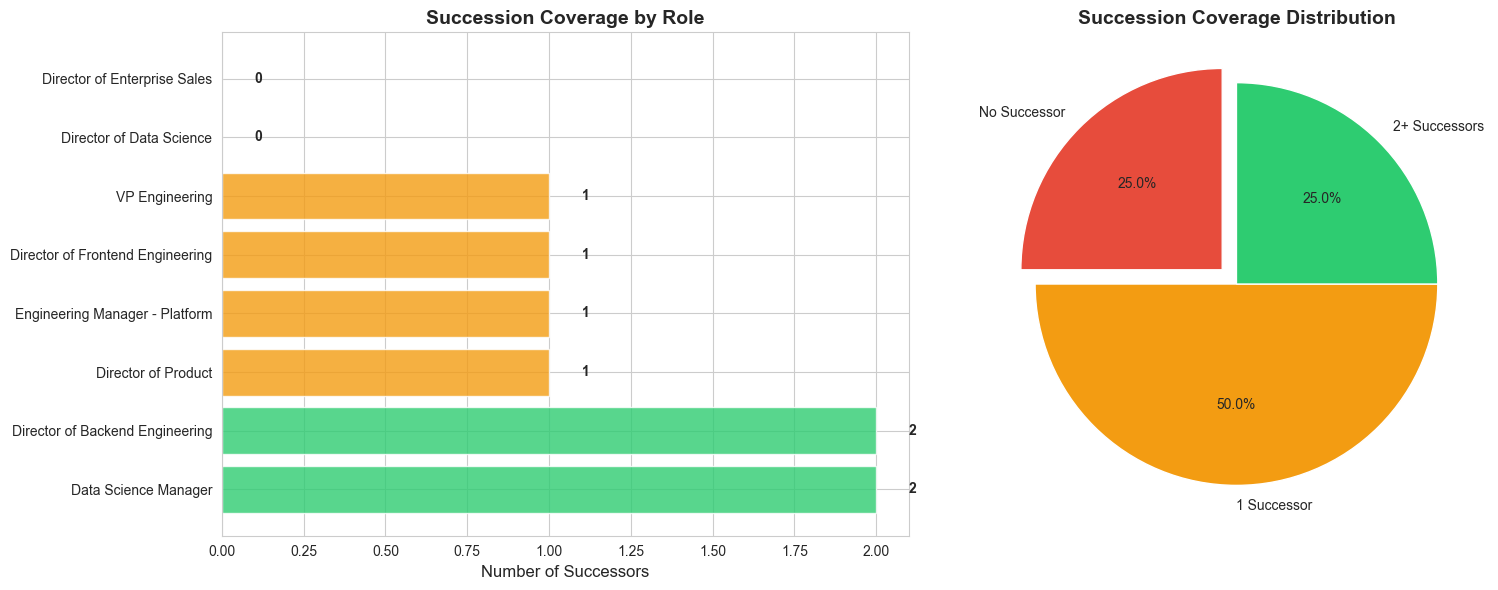

In [5]:
# Visualize succession coverage
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Coverage by role
coverage_sorted = coverage_analysis.sort_values('num_successors')
colors = ['#e74c3c' if x == 0 else '#f39c12' if x == 1 else '#2ecc71' 
          for x in coverage_sorted['num_successors']]

bars = ax1.barh(range(len(coverage_sorted)), coverage_sorted['num_successors'], 
                color=colors, alpha=0.8)
ax1.set_yticks(range(len(coverage_sorted)))
ax1.set_yticklabels(coverage_sorted['role_name'], fontsize=10)
ax1.set_xlabel('Number of Successors', fontsize=12)
ax1.set_title('Succession Coverage by Role', fontsize=14, fontweight='bold')
ax1.invert_yaxis()

# Add value labels
for i, val in enumerate(coverage_sorted['num_successors']):
    ax1.text(val + 0.1, i, str(val), va='center', fontweight='bold')

# Pie chart: Coverage categories
category_order = ['No Successor', '1 Successor', '2+ Successors']
category_values = [category_counts.get(cat, 0) for cat in category_order]
colors_pie = ['#e74c3c', '#f39c12', '#2ecc71']

ax2.pie(category_values, labels=category_order, autopct='%1.1f%%',
        colors=colors_pie, startangle=90, explode=(0.1, 0, 0))
ax2.set_title('Succession Coverage Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Successor Readiness Analysis

In [6]:
# Analyze successor readiness
readiness_counts = succession['readiness'].value_counts()

print("\nSUCCESSOR READINESS ANALYSIS")
print("="*70)
print(f"Total successors identified: {len(succession)}")
print("\nReadiness Distribution:")
for readiness, count in readiness_counts.items():
    pct = (count / len(succession)) * 100
    print(f"  {readiness}: {count} ({pct:.1f}%)")
print("="*70)

# Ready now count
ready_now = readiness_counts.get('Ready Now', 0)
print(f"\n⚠️  Only {ready_now} successors are 'Ready Now' ({ready_now/len(succession)*100:.1f}%)")
if ready_now < len(critical_roles) * 0.5:
    print("   → RECOMMENDATION: Accelerate development plans for high-priority successors")


SUCCESSOR READINESS ANALYSIS
Total successors identified: 8

Readiness Distribution:
  3+ Years: 3 (37.5%)
  1-2 Years: 3 (37.5%)
  2-3 Years: 2 (25.0%)

⚠️  Only 0 successors are 'Ready Now' (0.0%)
   → RECOMMENDATION: Accelerate development plans for high-priority successors


In [7]:
# Readiness by role
readiness_by_role = succession.groupby(['role_name', 'readiness']).size().unstack(fill_value=0)

print("\nREADINESS BY ROLE")
print("="*70)
print(readiness_by_role)
print("="*70)


READINESS BY ROLE
readiness                         1-2 Years  2-3 Years  3+ Years
role_name                                                       
Data Science Manager                      1          1         0
Director of Backend Engineering           1          0         1
Director of Frontend Engineering          0          1         0
Director of Product                       1          0         0
Engineering Manager - Platform            0          0         1
VP Engineering                            0          0         1


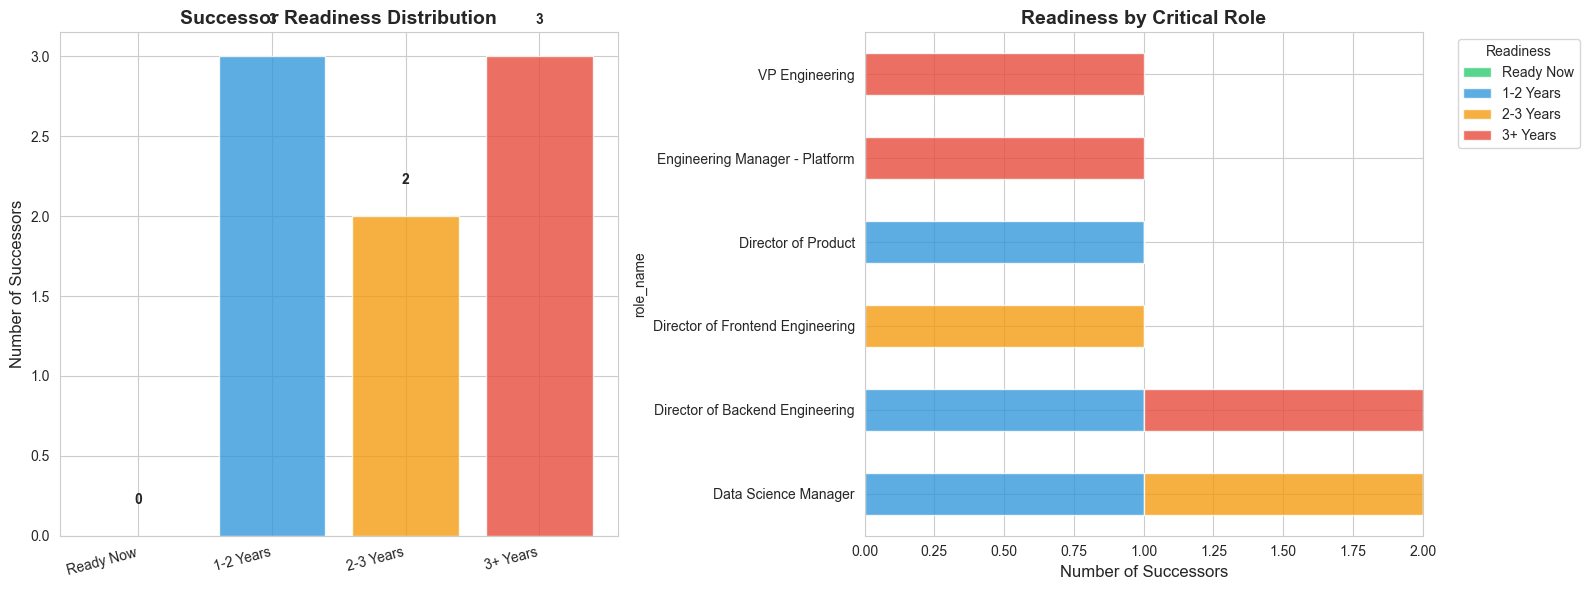

In [8]:
# Visualize readiness
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Readiness distribution
readiness_order = ['Ready Now', '1-2 Years', '2-3 Years', '3+ Years']
readiness_values = [readiness_counts.get(r, 0) for r in readiness_order]
colors_bar = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

bars = ax1.bar(range(len(readiness_order)), readiness_values, 
               color=colors_bar, alpha=0.8)
ax1.set_xticks(range(len(readiness_order)))
ax1.set_xticklabels(readiness_order, rotation=15, ha='right')
ax1.set_ylabel('Number of Successors', fontsize=12)
ax1.set_title('Successor Readiness Distribution', fontsize=14, fontweight='bold')

# Add value labels
for i, val in enumerate(readiness_values):
    ax1.text(i, val + 0.2, str(val), ha='center', fontweight='bold')

# Stacked bar: Readiness by role
if not readiness_by_role.empty:
    readiness_by_role_plot = readiness_by_role.reindex(columns=readiness_order, fill_value=0)
    readiness_by_role_plot.plot(kind='barh', stacked=True, ax=ax2, 
                                color=colors_bar, alpha=0.8)
    ax2.set_xlabel('Number of Successors', fontsize=12)
    ax2.set_title('Readiness by Critical Role', fontsize=14, fontweight='bold')
    ax2.legend(title='Readiness', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 4. High Potential Successor Analysis

In [9]:
# Analyze high potential successors
high_potential_successors = succession[succession['successor_high_potential'] == 1]

print("\nHIGH POTENTIAL SUCCESSORS")
print("="*70)
print(f"Total successors: {len(succession)}")
print(f"High potential successors: {len(high_potential_successors)} ({len(high_potential_successors)/len(succession)*100:.1f}%)")
print("="*70)

# High potential readiness
if len(high_potential_successors) > 0:
    print("\nHigh Potential Readiness:")
    hp_readiness = high_potential_successors['readiness'].value_counts()
    for readiness, count in hp_readiness.items():
        print(f"  {readiness}: {count}")

# Performance distribution
print("\nPerformance Distribution of Successors:")
print(f"  Average performance rating: {succession['successor_performance'].mean():.2f}")
print(f"  Min: {succession['successor_performance'].min():.2f}")
print(f"  Max: {succession['successor_performance'].max():.2f}")


HIGH POTENTIAL SUCCESSORS
Total successors: 8
High potential successors: 1 (12.5%)

High Potential Readiness:
  2-3 Years: 1

Performance Distribution of Successors:
  Average performance rating: 4.04
  Min: 3.71
  Max: 4.34


## 5. Succession Risk Heat Map

In [10]:
# Create risk assessment
# Risk = Criticality + Retirement Risk + Coverage Gap

def calculate_succession_risk(row):
    risk_score = 0
    
    # Criticality score
    if row['criticality'] == 'High':
        risk_score += 3
    elif row['criticality'] == 'Medium':
        risk_score += 2
    else:
        risk_score += 1
    
    # Retirement risk
    if row['incumbent_retirement_risk'] == 1:
        risk_score += 2
    
    # Successor coverage
    if row['num_successors'] == 0:
        risk_score += 3
    elif row['num_successors'] == 1:
        risk_score += 1
    
    return risk_score

coverage_analysis['risk_score'] = coverage_analysis.apply(calculate_succession_risk, axis=1)

# Categorize risk
def risk_category(score):
    if score >= 7:
        return 'High Risk'
    elif score >= 5:
        return 'Medium Risk'
    else:
        return 'Low Risk'

coverage_analysis['risk_category'] = coverage_analysis['risk_score'].apply(risk_category)
coverage_analysis_sorted = coverage_analysis.sort_values('risk_score', ascending=False)

print("\nSUCCESSION RISK ASSESSMENT")
print("="*90)
print(coverage_analysis_sorted[['role_name', 'criticality', 'incumbent_retirement_risk', 
                                'num_successors', 'risk_score', 'risk_category']].to_string(index=False))
print("="*90)

# Risk distribution
risk_counts = coverage_analysis['risk_category'].value_counts()
print("\nRisk Distribution:")
for risk in ['High Risk', 'Medium Risk', 'Low Risk']:
    count = risk_counts.get(risk, 0)
    pct = (count / len(coverage_analysis)) * 100
    print(f"  {risk}: {count} roles ({pct:.1f}%)")


SUCCESSION RISK ASSESSMENT
                       role_name criticality  incumbent_retirement_risk  num_successors  risk_score risk_category
    Director of Enterprise Sales        High                          0               0           6   Medium Risk
        Director of Data Science        High                          0               0           6   Medium Risk
                  VP Engineering        High                          0               1           4      Low Risk
Director of Frontend Engineering        High                          0               1           4      Low Risk
             Director of Product        High                          0               1           4      Low Risk
 Director of Backend Engineering        High                          0               2           3      Low Risk
  Engineering Manager - Platform      Medium                          0               1           3      Low Risk
            Data Science Manager      Medium                

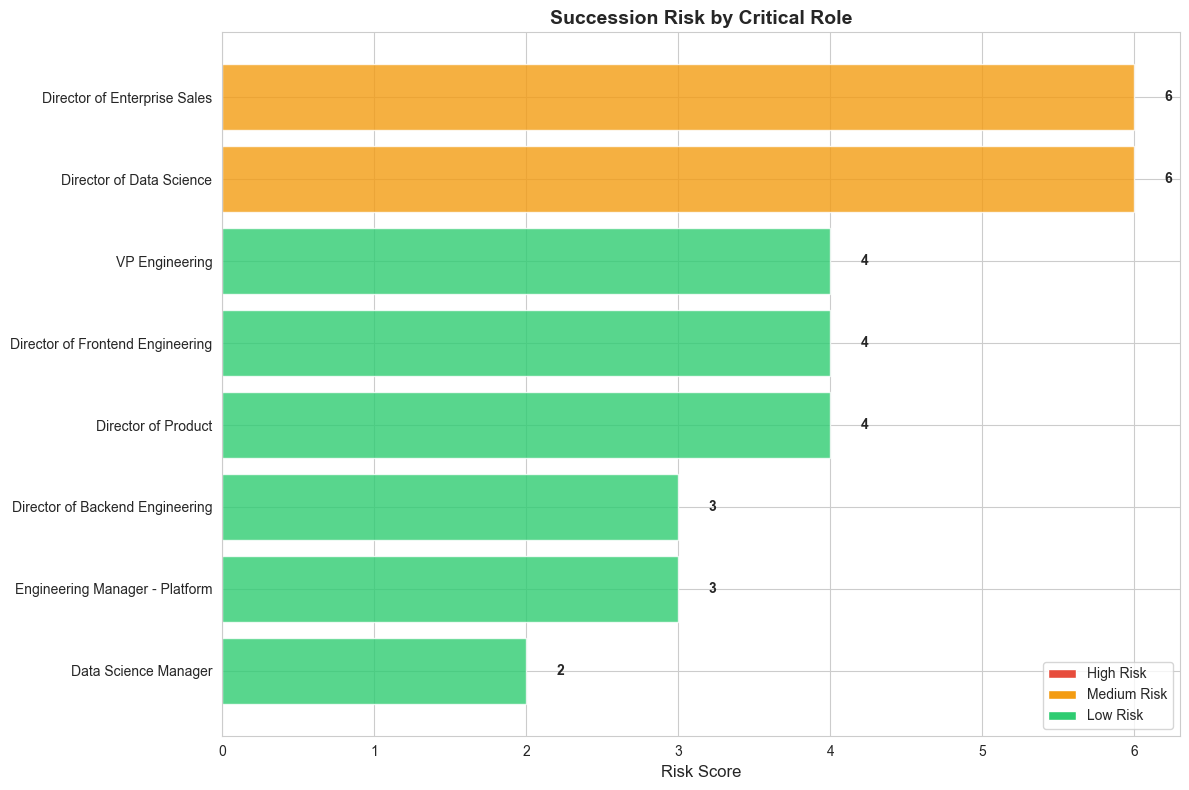

In [11]:
# Visualize succession risk
fig, ax = plt.subplots(figsize=(12, 8))

# Color by risk category
color_map = {'High Risk': '#e74c3c', 'Medium Risk': '#f39c12', 'Low Risk': '#2ecc71'}
colors = [color_map[cat] for cat in coverage_analysis_sorted['risk_category']]

bars = ax.barh(range(len(coverage_analysis_sorted)), 
               coverage_analysis_sorted['risk_score'], 
               color=colors, alpha=0.8)
ax.set_yticks(range(len(coverage_analysis_sorted)))
ax.set_yticklabels(coverage_analysis_sorted['role_name'], fontsize=10)
ax.set_xlabel('Risk Score', fontsize=12)
ax.set_title('Succession Risk by Critical Role', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels
for i, val in enumerate(coverage_analysis_sorted['risk_score']):
    ax.text(val + 0.2, i, str(val), va='center', fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='High Risk'),
    Patch(facecolor='#f39c12', label='Medium Risk'),
    Patch(facecolor='#2ecc71', label='Low Risk')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

## 6. Development Plan Tracking

In [12]:
# Development plans needed
needs_development = succession[succession['development_plan'] == 'Yes']

print("\nDEVELOPMENT PLAN REQUIREMENTS")
print("="*70)
print(f"Successors needing development: {len(needs_development)} of {len(succession)}")
print(f"Percentage: {len(needs_development)/len(succession)*100:.1f}%")
print("="*70)

# Group by readiness
dev_by_readiness = needs_development.groupby('readiness').size().reset_index(name='count')
print("\nDevelopment Needs by Readiness Timeline:")
print(dev_by_readiness.to_string(index=False))

print("\nDEVELOPMENT FOCUS AREAS:")
print("  1. Leadership training programs")
print("  2. Executive coaching and mentoring")
print("  3. Stretch assignments and project leadership")
print("  4. Cross-functional rotations")
print("  5. External executive education programs")


DEVELOPMENT PLAN REQUIREMENTS
Successors needing development: 8 of 8
Percentage: 100.0%

Development Needs by Readiness Timeline:
readiness  count
1-2 Years      3
2-3 Years      2
 3+ Years      3

DEVELOPMENT FOCUS AREAS:
  1. Leadership training programs
  2. Executive coaching and mentoring
  3. Stretch assignments and project leadership
  4. Cross-functional rotations
  5. External executive education programs


## 7. Key Recommendations

In [ ]:
print("\n" + "="*80)
print("KEY RECOMMENDATIONS")
print("="*80)

priority_num = 1

# Priority: Address high-risk roles (if any)
high_risk_roles = coverage_analysis[coverage_analysis['risk_category'] == 'High Risk']
if len(high_risk_roles) > 0:
    print(f"\n{priority_num}. URGENT: ADDRESS HIGH-RISK SUCCESSION GAPS")
    for _, role in high_risk_roles.iterrows():
        print(f"   → {role['role_name']} ({role['department']})")
        if role['num_successors'] == 0:
            print(f"      Action: Identify 1-2 potential successors by Q3 2026")
        else:
            print(f"      Action: Accelerate development plan for existing successor(s)")
    priority_num += 1

# Priority: Medium-risk roles
medium_risk_roles = coverage_analysis[coverage_analysis['risk_category'] == 'Medium Risk']
if len(medium_risk_roles) > 0:
    print(f"\n{priority_num}. ADDRESS MEDIUM-RISK SUCCESSION GAPS")
    for _, role in medium_risk_roles.iterrows():
        print(f"   → {role['role_name']} ({role['department']})")
        if role['num_successors'] == 0:
            print(f"      Action: Identify 1-2 potential successors by Q3 2026")
    priority_num += 1

# Priority: Roles with no successors
no_successors = coverage_analysis[coverage_analysis['num_successors'] == 0]
if len(no_successors) > 0:
    print(f"\n{priority_num}. IDENTIFY SUCCESSORS FOR {len(no_successors)} UNCOVERED ROLES")
    for _, role in no_successors.iterrows():
        print(f"   → {role['role_name']} ({role['department']}, {role['criticality']} criticality)")
    priority_num += 1

# Priority: Development plans
print(f"\n{priority_num}. IMPLEMENT DEVELOPMENT PLANS")
print(f"   → {len(needs_development)} successors require development")
print(f"   → Focus on '1-2 Years' readiness group first ({len(needs_development[needs_development['readiness'] == '1-2 Years'])} successors)")
print(f"   → Assign executive coaches/mentors")
print(f"   → Create stretch assignment opportunities")
priority_num += 1

# Priority: Succession review cadence
print(f"\n{priority_num}. ESTABLISH REGULAR SUCCESSION REVIEW PROCESS")
print("   → Quarterly talent reviews with business leaders")
print("   → Bi-annual succession plan updates")
print("   → Track development plan progress monthly")
print("   → Update high-potential designation annually")
priority_num += 1

# Priority: Succession metrics
print(f"\n{priority_num}. TARGET METRICS")
print(f"   → Succession coverage goal: >90% (Current: {coverage_rate:.1f}%)")
print(f"   → 'Ready Now' successors: >40% (Current: {ready_now/len(succession)*100:.1f}%)")
print(f"   → Average successors per role: >1.5 (Current: {len(succession)/len(critical_roles):.1f})")

print("\n" + "="*80)
print("Strategic Workforce Planning Complete!")
print("Review all three notebooks for comprehensive workforce strategy.")
print("="*80)